In [76]:

import numpy as np
import matplotlib.pyplot as plt
import helpers as hp
from pathlib import Path
from config import PathConfigs
import os
import pandas as pd
import plotly.graph_objects as go
import multiprocessing as mp
from __future__ import annotations
from dataclasses import dataclass, asdict
from typing import Optional, Any, Dict
from scipy.constants import hbar, m_e, eV, physical_constants
import os, json
import itertools as itr
from tqdm import tqdm
from functools import partial


In [77]:
s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

szs0 = np.kron(sz, s0)
szsx = np.kron(sz, sx)
sysy = np.kron(sy, sy)
szsy = np.kron(sz, sy)

S = np.kron(sx, np.eye(2))


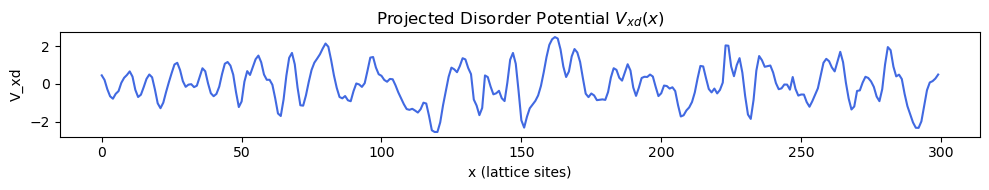

ΔVd = -0.0000
sqrt[<Vxd²>] = 1.0000


In [78]:
fname = Path(PathConfigs.RUN_FILES/"New_Disorders"/"Tdis.npz")
Vdisx = np.load(fname)['Vdisx']
Nx = len(Vdisx)
plt.figure(figsize=(10, 2))
plt.plot(np.arange(Nx), Vdisx, color='royalblue')
plt.xlabel("x (lattice sites)")
plt.ylabel("V_xd")
plt.title("Projected Disorder Potential $V_{xd}(x)$")
plt.gca().set_aspect('auto')
plt.tight_layout()
plt.show()

# mean and variance
DeltaVd = np.mean(Vdisx)
VarVd = np.mean(Vdisx**2)
print(f"ΔVd = {DeltaVd:.4f}")
print(f"sqrt[<Vxd²>] = {np.sqrt(VarVd):.4f}")


In [ ]:
@dataclass(frozen=True)
class Config:
    
    #Algorithm parameters
    Nx: int = 300 # number of lattice sites
    Disorder_amplitude: float = 1.2 # meV
    rashba_soc: float = 140.0 # meV*Angstrom
    ms: float = 0.023 # effective mass in units of electron mass
    lattice_const: float = 100.0 # Angstrom
    etam: float = ((hbar**2) * (10**20.0)) / (m_e*eV) #Constant to convert to meV
    ts: float = (1e3 * etam) / (2.0 * (lattice_const**2.0) * ms) # meV
    alphas: float = rashba_soc/lattice_const
    gamma: float = 0.2 # meV
    Delta0: float = 0.3
    Delta_ind: float = (Delta0 * gamma)/(Delta0 + gamma)
    Z: float = Delta0/(gamma + Delta0) # renormalization factor
    
    #Parameter sweep ranges
    
    Vz_max: float = 1.0# meV
    Vz_min: float = 0.4 # meV
    Vz_res: int = 0.02 # spacing of sweep
    Nvz:    int = int(np.floor((Vz_max - Vz_min)/Vz_res)) # number of points for sweep
    
    mu_max: float = 4.5
    mu_min: float = 0.00
    mu_res: float = 0.02
    Nmu:    int   = int(np.floor((mu_max - mu_min)/mu_res))
    
    
    Vdisx: np.array = Vdisx
    
    qn: int = 20
    
    
cfg = Config()
Length = cfg.Nx

mu_var = np.linspace(cfg.mu_min, cfg.mu_max, cfg.Nmu)
Vz_var = np.linspace(cfg.Vz_min, cfg.Vz_max, cfg.Nvz)



In [80]:
h1 = np.array([
    [- cfg.ts,         -cfg.alphas / 2,  0,           0         ],
    [ cfg.alphas / 2, - cfg.ts,          0,           0         ],
    [ 0,           0,            cfg.ts,          cfg.alphas / 2],
    [ 0,           0,          -cfg.alphas / 2,   cfg.ts        ]
], dtype=complex)

h1T = h1.T

def h0(gm, mu):
    """
    Python translation of the normal-state base Hamiltonian h0[\[CapitalGamma]_, \[Mu]_]
    
    Parameters:
    - gm (float): Represents \[CapitalGamma]
    - mu (float): Represents the chemical potential \[Mu]
    
    Assumes `ts` and `gamma` are defined in the global scope before this function is called.
    """
    
    # Constructing the 4x4 matrix exactly as represented in the table
    matrix = np.array([
        [ 2*cfg.ts - mu,  gm,          0,           cfg.gamma ],
        [ gm,         2*cfg.ts - mu,  -cfg.gamma,       0     ],
        [ 0,         -cfg.gamma,      -2*cfg.ts + mu,  -gm    ],
        [ cfg.gamma,      0,          -gm,         -2*cfg.ts + mu]
    ], dtype=complex)
    
    return matrix

In [81]:
zero4 = np.zeros((4, 4), dtype=complex)

# Assumes h1 and h1T were defined previously, as we did in the last step!
# Example placeholder if running this isolated:
# h1 = np.zeros((4, 4), dtype=complex) 
# h1T = h1.T

# 2. TT: Block matrix using np.block (equivalent to ArrayFlatten)
TT = np.block([
    [h1,    zero4],
    [zero4, h1T  ]
])

# 3. TT1: Block matrix with transposed positions
TT1 = np.block([
    [h1T,   zero4],
    [zero4, h1   ]
])

# 4. H1 function
def H1(gm, mu, V0, ii):
    """
    Python translation of H1[\[CapitalGamma]_, \[Mu]_, V0_, ii_]
    Adds the disorder potential to the diagonal of the base Hamiltonian h0.
    """
    # Create a copy so we don't accidentally mutate the base h0 matrix
    htp = h0(gm, mu).copy() 
    
    # ii is passed as a 1-based index (1 to Nx), so we subtract 1 for the Python array
    # Assumes Vdiss is a globally defined NumPy array
    v_disorder = V0 * cfg.Vdisx[ii - 1]
    
    # Apply to the diagonal using 0-based indexing
    htp[0, 0] += v_disorder
    htp[1, 1] += v_disorder
    htp[2, 2] -= v_disorder
    htp[3, 3] -= v_disorder
    
    return htp

In [82]:
def SigR(gm, mu, V0):
    """
    Python translation of SigR[\[CapitalGamma]_, \[Mu]_, V0_]
    Assumes Nx, h1, h1T, zero4, TT, and TT1 are globally available.
    """
    sgtp = np.zeros((8, 8))
    sgrtp = [sgtp]
    
    gg0 = np.block([
        [H1(gm, mu, V0, int(Nx/2)), h1],
        [h1T, H1(gm, mu, V0, int(Nx/2) + 1)]
    ])
    
    grtp = np.linalg.inv(-gg0 - sgtp)
    sgtp = TT @ grtp @ TT1
    sgrtp.append(sgtp)
    
    # Mathematica loop: For[ii = Nx/2 - 1, ii >= 2, ii--]
    # In Python, the range ends before '1', so it stops at '2'
    for ii in range(int(Nx/2) - 1, 1, -1):
        
        gg0 = np.block([
            [H1(gm, mu, V0, ii), zero4],
            [zero4, H1(gm, mu, V0, Nx - ii + 1)]
        ])
        
        grtp = np.linalg.inv(-gg0 - sgtp)
        sgtp = TT @ grtp @ TT1
        sgrtp.append(sgtp)
        
    return sgrtp


def SigL(gm, mu, V0, q):
    """
    Python translation of SigL[\[CapitalGamma]_, \[Mu]_, V0_, q_]
    Assumes Nx, h1, h1T, zero4, TT, and TT1 are globally available.
    """
    sgtp = np.zeros((8, 8))
    sgltp = [sgtp]
    
    gg0 = np.block([
        [H1(gm, mu, V0, 1), h1T * np.exp(-1.0j * Nx * q)],
        [h1 * np.exp(1.0j * Nx * q), H1(gm, mu, V0, Nx)]
    ])
    
    gltp = np.linalg.inv(-gg0 - sgtp)
    sgtp = TT1 @ gltp @ TT
    sgltp.append(sgtp)
    
    # Mathematica loop: For[ii = 2, ii <= Nx/2 - 1, ii++]
    # In Python, range ends before int(Nx/2), so it stops at int(Nx/2) - 1
    for ii in range(2, int(Nx/2)):
        
        gg0 = np.block([
            [H1(gm, mu, V0, ii), zero4],
            [zero4, H1(gm, mu, V0, Nx - ii + 1)]
        ])
        
        gltp = np.linalg.inv(-gg0 - sgtp)
        sgtp = TT1 @ gltp @ TT
        sgltp.append(sgtp)
        
    return sgltp

In [83]:
def G0(gm, mu, V0, q):
    """
    Python translation of the Mathematica G0[\[CapitalGamma]_, \[Mu]_, V0_, q_]
    Assumes Nx, zero4, TT, TT1, h1, h1T, and sigr are globally available or passed in.
    """
    sigl = SigL(gm, mu, V0, q)
    sigr = SigR(gm, mu, V0)
    
    # ----------- First Block (Before Loop) -----------
    block1 = np.block([
        [-H1(gm, mu, V0, 1), -h1T * np.exp(-1.0j * Nx * q)],
        [-h1 * np.exp(1.0j * Nx * q), -H1(gm, mu, V0, Nx)]
    ])
    
    block2 = np.block([
        [-H1(gm, mu, V0, 2), zero4],
        [zero4, -H1(gm, mu, V0, Nx - 1)]
    ])
    
    # Note: sigl[[1]] becomes sigl[0], and sigr[[Nx/2 - 1]] becomes sigr[int(Nx/2) - 2]
    gtp = np.linalg.inv(np.block([
        [block1 - sigl[0], -TT],
        [-TT1, block2 - sigr[int(Nx/2) - 2]]
    ]))
    
    gg0 = gtp
    
    # ----------- Loop (For[ii = 2, ii <= Nx/2 - 2, ii++]) -----------
    # Python range is exclusive at the top, so we go up to int(Nx/2) - 1
    for ii in range(2, int(Nx/2) - 1):
        
        block_ii_1 = np.block([
            [-H1(gm, mu, V0, ii), zero4],
            [zero4, -H1(gm, mu, V0, Nx - ii + 1)]
        ])
        
        block_ii_2 = np.block([
            [-H1(gm, mu, V0, ii + 1), zero4],
            [zero4, -H1(gm, mu, V0, Nx - ii)]
        ])
        
        # sigl[[ii]] -> sigl[ii - 1]
        # sigr[[Nx/2 - ii]] -> sigr[int(Nx/2) - ii - 1]
        gtp = np.linalg.inv(np.block([
            [block_ii_1 - sigl[ii - 1], -TT],
            [-TT1, block_ii_2 - sigr[int(Nx/2) - ii - 1]]
        ]))
        
        gg0 = gg0 + gtp
        
    # ----------- Block After Loop -----------
    block_end_1 = np.block([
        [-H1(gm, mu, V0, int(Nx/2) - 1), zero4],
        [zero4, -H1(gm, mu, V0, int(Nx/2) + 2)]
    ])
    
    block_end_2 = np.block([
        [-H1(gm, mu, V0, int(Nx/2)), -h1],
        [-h1T, -H1(gm, mu, V0, int(Nx/2) + 1)]
    ])
    
    # sigl[[Nx/2 - 1]] -> sigl[int(Nx/2) - 2]
    # sigr[[1]] -> sigr[0]
    gtp = np.linalg.inv(np.block([
        [block_end_1 - sigl[int(Nx/2) - 2], -TT],
        [-TT1, block_end_2 - sigr[0]]
    ]))
    
    gg0 = gg0 + gtp
    
    # ----------- gg1 and gg2 Calculations -----------
    gg1_block = np.block([
        [-H1(gm, mu, V0, 1), -h1T * np.exp(-1.0j * Nx * q)],
        [-h1 * np.exp(1.0j * Nx * q), -H1(gm, mu, V0, Nx)]
    ])
    gg1 = np.linalg.inv(gg1_block - sigr[int(Nx/2) - 1])
    
    gg2_block = np.block([
        [-H1(gm, mu, V0, int(Nx/2)), -h1],
        [-h1T, -H1(gm, mu, V0, int(Nx/2) + 1)]
    ])
    gg2 = np.linalg.inv(gg2_block - sigl[int(Nx/2) - 1])
    
    return gg0, gg1, gg2
 

In [84]:
def fq(gm, mu, V0, NL):
    """
    Python translation of fq[\[CapitalGamma]_, \[Mu]_, V0_, NL_]
    Calculates the winding number (periodic disorder invariant) for a given set of parameters.
    """
    # We declare sigr as global so that the G0 function can access it 
    # without needing to pass it explicitly through fg() -> G0()
    global sigr
    
    ntp = 0.0
    delta_q = 2.0 * np.pi / (Nx * NL)
    
    # -Max[Round[0.075 NL], 1]*\[Delta]q
    q0 = -max(round(0.075 * NL), 1) * delta_q
    
    # Calculate Right Self-Energy once per parameter set
    sigr = SigR(gm, mu, V0)
    
    # --- First For Loop ---
    # Standard integration steps for the bulk of the Brillouin zone
    qq = -1.0 * np.pi / Nx
    while qq < q0 - 0.00001:
        g12, g21 = fg(gm, mu, V0, qq)
        
        # Tr[S . (h1T . g12 - h1 . g21)]
        trace_val = np.trace(S @ (h1T @ g12 - h1 @ g21))
        ntp += trace_val
        
        qq += delta_q
        
    # --- Second For Loop ---
    # Finer integration steps (0.1 * delta_q) near q = 0 to catch sharp peaks
    qq = q0 + 0.1 * delta_q / 2.0
    while qq < -0.00001:
        g12, g21 = fg(gm, mu, V0, qq)
        
        # 0.1 Tr[S . (h1T . g12 - h1 . g21)]
        trace_val = np.trace(S @ (h1T @ g12 - h1 @ g21))
        ntp += 0.1 * trace_val
        
        qq += 0.1 * delta_q
        
    # --- Calculate Final Invariant ---
    # Re[-ntp/NL]
    invariant = np.real(-ntp / NL)
    
    # Chop[..., 10^-4] sets anything smaller than 1e-4 to 0.0
    if abs(invariant) < 1e-4:
        invariant = 0.0
        
    return invariant



def fg(gm, mu, V0, q):
    """
    Python translation of the Mathematica fg[\[CapitalGamma]_, \[Mu]_, V0_, q_]
    """
    # Get the tuple of matrices from G0
    GG = G0(gm, mu, V0, q)
    gg0 = GG[0]
    gg1 = GG[1]
    gg2 = GG[2]
    
    # gg12 calculation 
    # Mathematica: GG[[1, 1 ;; 4, 9 ;; 12]] -> Python: gg0[0:4, 8:12]
    gg12 = (
        gg0[0:4, 8:12] + 
        gg0[12:16, 4:8] + 
        np.exp(-1.0j * Nx * q) * gg1[4:8, 0:4] + 
        gg2[0:4, 4:8]
    ) / Nx
    
    # gg21 calculation
    # Mathematica: GG[[1, 9 ;; 12, 1 ;; 4]] -> Python: gg0[8:12, 0:4]
    gg21 = (
        gg0[8:12, 0:4] + 
        gg0[4:8, 12:16] + 
        np.exp(1.0j * Nx * q) * gg1[0:4, 4:8] + 
        gg2[4:8, 0:4]
    ) / Nx
    
    return gg12, gg21




In [ ]:

# ==========================================
# 1. The Worker Function
# ==========================================
def worker_pdi_step(param_tuple):
    """
    Evaluates the periodic disorder invariant for a single (mu, gm) pair.
    """
    mu, gm, V0_val, NL_val = param_tuple
    
    Q_nu = fq(gm, mu, V0_val, NL_val)
    
    if 0.05 < abs(Q_nu - int(Q_nu)) < 0.95:
        Q_nu = fq(gm, mu, V0_val, 2 * NL_val)
        
        if 0.1 < abs(Q_nu - int(Q_nu)) < 0.9:
            Q_nu = fq(gm, mu, V0_val, 5 * NL_val)
            
            if 0.1 < abs(Q_nu - int(Q_nu)) < 0.9:
                Q_nu = fq(gm, mu, V0_val, 10 * NL_val) 
                
    pdi_value = int(np.round(Q_nu))
    
    return [mu, gm, pdi_value]

# ==========================================
# 2. Main Execution Block
# ==========================================
if __name__ == '__main__':
    # Define your global-level variables here if they aren't already
    # V0 = 1.2
    # NL = 20
    
    # Generate the parameter ranges
    mu_vals = np.linspace(cfg.mu_min, cfg.mu_max, cfg.Nmu)
    gm_vals = np.linspace(cfg.Vz_min, cfg.Vz_max, cfg.Nvz)
    
    # Create a flat list of all parameter combinations to evaluate
    params_list = [(mu, gm, cfg.Disorder_amplitude, cfg.qn) for mu in mu_vals for gm in gm_vals]
    
    nu_map = []
    
    # Set up the multiprocessing pool
    num_workers = 8
    
    print(f"Starting parallel phase diagram scan using {num_workers} cores...")
    
    with mp.Pool(processes=num_workers) as pool:
        # pool.imap evaluates the list in parallel but yields results in the exact original order
        results_iterator = pool.imap(worker_pdi_step, params_list)
        
        # tqdm provides a nice progress bar
        for res in tqdm(results_iterator, total=len(params_list), desc="Phase Diagram Sweep"):
            nu_map.append(res)
            
    # ==========================================
    # 3. Post-Processing
    # ==========================================
    # Convert directly to an N x 3 numpy array
    nu_map = np.array(nu_map)
    
    print(f"\nFinished! nu_map shape: {nu_map.shape}")

Starting parallel phase diagram scan using 8 cores...


Phase Diagram Sweep: 100%|██████████| 750/750 [18:31<00:00,  1.48s/it]  


Finished! nu_map shape: (750, 3)


In [87]:
def filter_pdi(pdis, thresh = 0.8):
    for i in range(len(pdis)):
        pdi = pdis[i]
        if pdi > 1.0:
            pdis[i] = 1.00
        elif pdi < 0.0:
            pdis[i] = 0
        
        if thresh:
            if pdi > thresh:
                pdis[i] =  1
            else:
                pdis[i] =  0
    return pdis



# Assuming pdi_arr and filter_pdi are already defined in your environment
mu = nu_map[:, 0]    # y-axis in the plot
V_z = nu_map[:, 1]   # x-axis in the plot
I = filter_pdi(nu_map[:, 2])  # z-axis (color)
#I = nu_map[:, 2]  # z-axis (color)

# Create the interactive Plotly heatmap/contour
fig = go.Figure(data=go.Contour(
    x=V_z,
    y=mu,
    z=I,
    colorscale='Viridis',  # Matches Matplotlib's 'viridis'
    ncontours=100,         # Matches the levels=100 argument
    line_width=0,          # Removes contour lines for a smooth heatmap look
    contours=dict(
        coloring='heatmap',
        showlines=False
    ),
    colorbar=dict(
        title='Intensity (I)'
    )
))

# Label axes and title
# Plotly naturally renders LaTeX enclosed in $ symbols
fig.update_layout(
    title='Winding Number (I vs $\\mu$ and $V_z$)',
    xaxis_title='$V_z$',
    yaxis_title='$\\mu$',
    xaxis_range=[0.3, 1.2],  # <-- SET YOUR X-AXIS LIMITS HERE
    yaxis_range=[1, 4.5],
    width=400,
    height=700
)

fig.show()
    